In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cenario = "NDT"
method = "cusum"
file = "Curi_MLAB1-SP02_s01"
metric = "tp_up"
merge_path = f"results/{cenario}/full/{method}/{file}.csv"
series_path = f"series/{cenario}/full/{file}.csv"
if method.startswith("vwcd"):
    P_metric_path = f"results/{cenario}/{metric}/{method}/tail_probability_theta_ge_Tstar/{file}.csv"
else:
    P_metric_path = f"results/{cenario}/{metric}/{method}/{file}.csv"
df_merge = pd.read_csv(merge_path)
df_series = pd.read_csv(series_path)
df_P_metric = pd.read_csv(P_metric_path)

df_merge['timestamp'] = pd.to_datetime(df_merge['timestamp'])
df_P_metric['timestamp'] = pd.to_datetime(df_P_metric['timestamp'])
df_series['timestamp'] = pd.to_datetime(df_series['timestamp'])

df_series.rename(columns={
    'rtt_download': 'rtt_down',
    'throughput_download': 'tp_down',
    'rtt_upload': 'rtt_up',
    'throughput_upload': 'tp_up',
    'packet_loss': 'pl'
}, inplace=True)

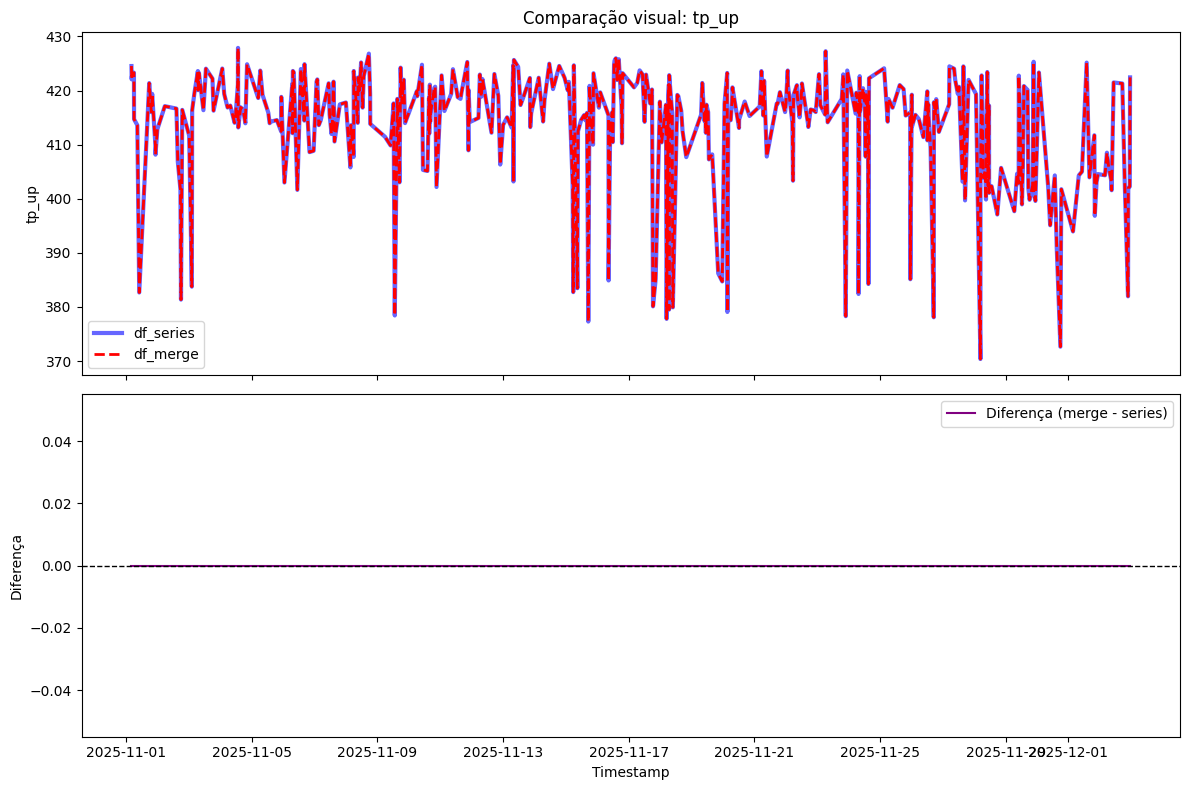

In [82]:
import matplotlib.pyplot as plt
import pandas as pd

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(df_series['timestamp'], pd.to_numeric(df_series[metric]), 
         label='df_series', color='blue', alpha=0.6, linewidth=3)
ax1.plot(df_merge['timestamp'], pd.to_numeric(df_merge[metric]), 
         label='df_merge', color='red', linestyle='--', linewidth=2)
ax1.set_ylabel(metric)
ax1.set_title(f'Comparação visual: {metric}')
ax1.legend()

diferenca = (pd.to_numeric(df_merge.set_index('timestamp')[metric]) - pd.to_numeric(df_series.set_index('timestamp')[metric])).dropna()
ax2.plot(df_merge['timestamp'], diferenca, color='purple', label='Diferença (merge - series)')
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_ylabel('Diferença')
ax2.set_xlabel('Timestamp')
ax2.legend()

plt.tight_layout()
plt.show()

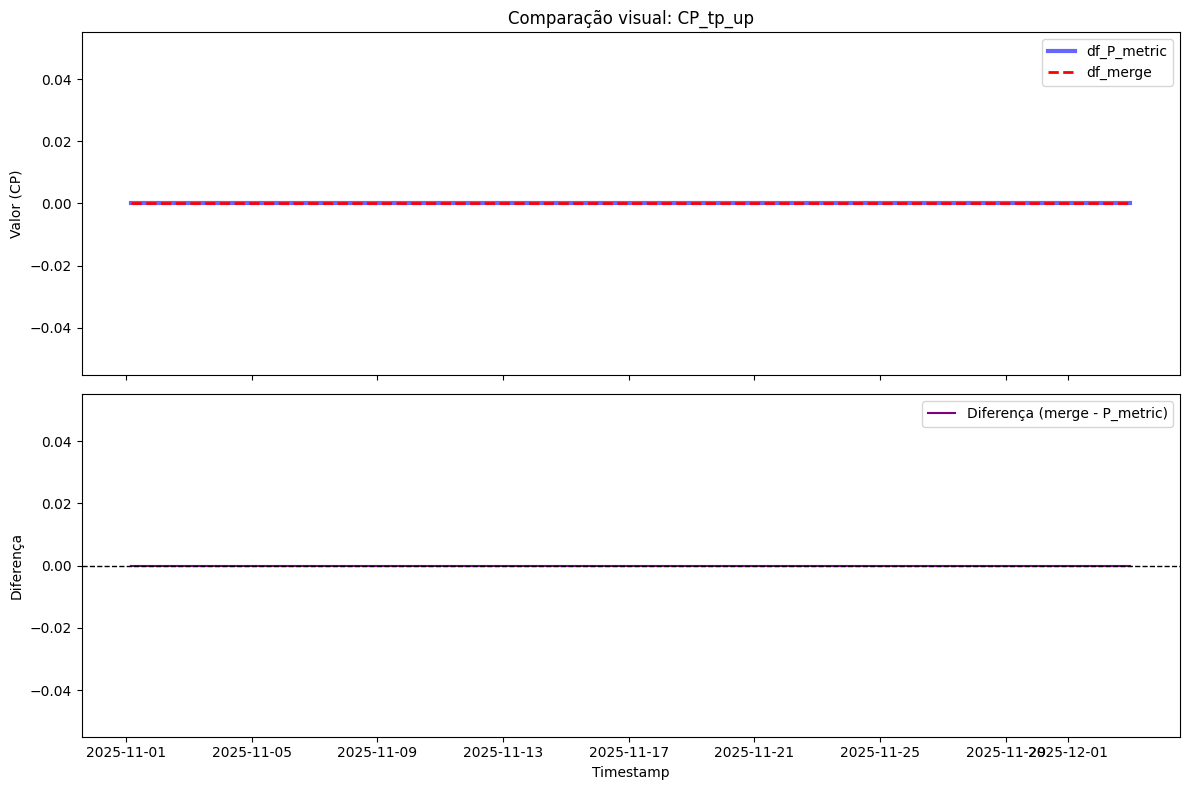

In [83]:
import matplotlib.pyplot as plt
import pandas as pd

if method.lower().startswith("vwcd"):
    col_merge = f'P_{metric}'
    col_original = 'P_theta_ge_Tstar'
    y_label = 'Probabilidade'
else:
    col_merge = f'CP_{metric}'
    col_original = 'CP'
    y_label = 'Valor (CP)'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(df_P_metric['timestamp'], pd.to_numeric(df_P_metric[col_original]), 
         label='df_P_metric', color='blue', alpha=0.6, linewidth=3)
ax1.plot(df_merge['timestamp'], pd.to_numeric(df_merge[col_merge]), 
         label='df_merge', color='red', linestyle='--', linewidth=2)
ax1.set_ylabel(y_label)
ax1.set_title(f'Comparação visual: {col_merge}')
ax1.legend()

diferenca = pd.to_numeric(df_merge[col_merge]) - pd.to_numeric(df_P_metric[col_original])
ax2.plot(df_merge['timestamp'], diferenca, color='purple', label='Diferença (merge - P_metric)')
ax2.axhline(0, color='black', linestyle='--', linewidth=1)
ax2.set_ylabel('Diferença')
ax2.set_xlabel('Timestamp')
ax2.legend()

plt.tight_layout()
plt.show()